# Turbofan Failure Detection: TCN vs Autoencoder

**Min (Spirits) del av gruppprojektet — kopplar ihop TCN och Autoencoder**

Det här är min del av gruppens TCN/Autoencoders-mikroprojekt. Emmy bygger TCN-modellen
(slide 1-5), Mahtab bygger Autoencoder-modellen (slide 6-10), och min uppgift (slide 11-15)
är att koppla ihop de två modellerna utifrån föreläsningens översiktsbilder, förklara hur de
fungerar på en högre nivå, och avsluta med affärsvärde och slutsats.

**Därför bygger jag ändå en egen version av båda modellerna här:** för att kunna visa,
block för block, hur föreläsningens abstrakta diagram (kernels/dilated convolutions för TCN,
encoder/bottleneck/decoder för Autoencoder) faktiskt manifesterar sig i riktig kod och riktig
data från våra jetmotorer. Varje sektion nedan är döpt efter och kopplad till en specifik ruta
i föreläsningsbilderna.

**Story:** Kan vi upptäcka om en motor är på väg att gå sönder — innan den faktiskt havererar?

**Idé:** TCN och Autoencoder svarar på två olika frågor om samma nedbrytningsprocess:
- **TCN** — *"Blev modellen förvånad?"* Förutspår nästa sensoravläsning. Stor avvikelse =
  tecken på en snabb slitageförändring.
- **Autoencoder** — *"Känner den igen helheten?"* Återskapar ett helt sensorfönster. Misslyckas
  den = tecken på en successiv slitageförändring.

Vi letar inte efter vilken teknik som är bäst på att förutsäga slitage rent generellt, utan
vilken av de två frågeställningarna som ger tydligast varning för just den här sortens
(gradvisa) slitage.

**Dataset:** [NASA Turbofan Jet Engine Degradation (C-MAPSS)](https://www.kaggle.com/datasets/behrad3d/nasa-cmaps),
delmängd FD001 — simulerad sensordata (ej riktiga flygningar) från passagerarflygplans-motorer.

In [1]:
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models

from sklearn.preprocessing import StandardScaler

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_theme(style="whitegrid")

FIG_DIR = Path("../reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(name):
    plt.savefig(FIG_DIR / f"spirit_{name}.png", dpi=150, bbox_inches="tight")

print("TensorFlow-version:", tf.__version__)

TensorFlow-version: 2.21.0


**Vad gör det här blocket?**

Standardimporter: `tensorflow.keras` för att bygga TCN- och Autoencoder-modellerna,
`sklearn.preprocessing.StandardScaler` för att normalisera sensordata, `matplotlib`/`seaborn`
för alla grafer. Samma seed-mönster som i förra projektet för reproducerbara resultat, och
samma `save_fig()`-hjälpfunktion så att varje nyckelgraf sparas som en egen PNG för
presentationen.

In [2]:
DATA_DIR = Path("../data/raw/CMAPSSData")

COLS = ["unit", "cycle", "os1", "os2", "os3"] + [f"s{i}" for i in range(1, 22)]

def load_cmapss(filename):
    return pd.read_csv(DATA_DIR / filename, sep=r"\s+", header=None, names=COLS)

train_df = load_cmapss("train_FD001.txt")
test_df = load_cmapss("test_FD001.txt")
rul_df = pd.read_csv(DATA_DIR / "RUL_FD001.txt", sep=r"\s+", header=None, names=["RUL_at_cutoff"])
rul_df["unit"] = rul_df.index + 1

print(f"Träning: {train_df['unit'].nunique()} motorer, {len(train_df)} rader")
print(f"Test:    {test_df['unit'].nunique()} motorer, {len(test_df)} rader")
train_df.head()

Träning: 100 motorer, 20631 rader
Test:    100 motorer, 13096 rader


,unit,cycle,os1,os2,os3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


**Vad gör det här blocket?**

Läser in de tre FD001-filerna. Varje rad är en **cykel** (ungefär en flygning) för en viss
motor (`unit`). Kolumnerna är: motor-ID, cykelnummer, 3 driftsinställningar (`os1-os3`), och
21 sensoravläsningar (`s1-s21`).

`train_FD001.txt` innehåller 100 motorer körda från frisk drift ända fram till haveri —
det är detta vi tränar på. `test_FD001.txt` innehåller 100 andra motorer där mätningen klipps
av **innan** haveriet, och `RUL_FD001.txt` ger facit: hur många cykler till haveri var kvar
när mätningen klipptes av. Det är det facitet vi till slut ska validera våra larm mot.

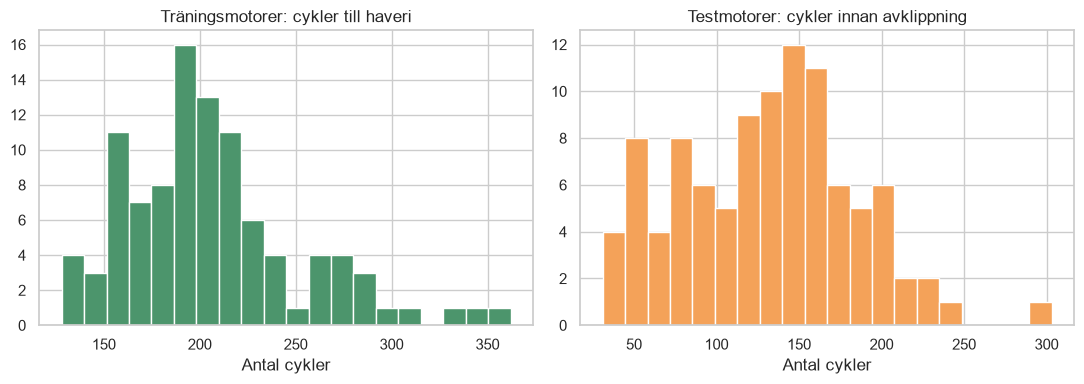

Träning: 128-362 cykler per motor (medel 206)
Test:    31-303 cykler per motor (medel 131)


In [3]:
train_lengths = train_df.groupby("unit")["cycle"].max()
test_lengths = test_df.groupby("unit")["cycle"].max()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(train_lengths, bins=20, color="#4C956C")
axes[0].set_title("Träningsmotorer: cykler till haveri")
axes[0].set_xlabel("Antal cykler")
axes[1].hist(test_lengths, bins=20, color="#F4A259")
axes[1].set_title("Testmotorer: cykler innan avklippning")
axes[1].set_xlabel("Antal cykler")
plt.tight_layout()
save_fig("cycle_length_distribution")
plt.show()

print(f"Träning: {train_lengths.min()}-{train_lengths.max()} cykler per motor (medel {train_lengths.mean():.0f})")
print(f"Test:    {test_lengths.min()}-{test_lengths.max()} cykler per motor (medel {test_lengths.mean():.0f})")

**Vad gör det här blocket?**

Visar hur länge motorerna körs innan de går sönder (träning) respektive innan mätningen
klipps av (test). Träningsmotorerna körs mellan ~130 och ~360 cykler innan haveri — det är
en stor spridning, vilket gör att en enkel "efter X cykler går den sönder"-regel aldrig hade
fungerat. Det är precis därför vi behöver en modell som lär sig känna igen *mönster* i
sensordatan snarare än att bara räkna cykler.

Droppar 7 i princip konstanta sensorer: ['s1', 's5', 's6', 's10', 's16', 's18', 's19']
Behåller 14 sensorer: ['s2', 's3', 's4', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']


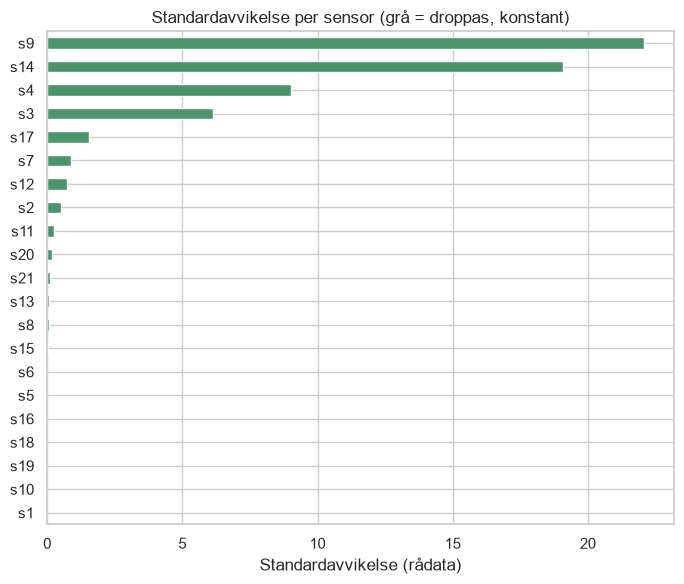

In [4]:
sensor_cols_all = [f"s{i}" for i in range(1, 22)]
stds = train_df[sensor_cols_all].std()

CONSTANT_SENSORS = stds[stds < 0.01].index.tolist()  # täcker även s6, som är nästan (men inte helt) konstant
SENSOR_COLS = [c for c in sensor_cols_all if c not in CONSTANT_SENSORS]

print(f"Droppar {len(CONSTANT_SENSORS)} i princip konstanta sensorer: {CONSTANT_SENSORS}")
print(f"Behåller {len(SENSOR_COLS)} sensorer: {SENSOR_COLS}")

stds.sort_values().plot(kind="barh", figsize=(7, 6), color=[
    "#c0c0c0" if c in CONSTANT_SENSORS else "#4C956C" for c in stds.sort_values().index
])
plt.title("Standardavvikelse per sensor (grå = droppas, konstant)")
plt.xlabel("Standardavvikelse (rådata)")
plt.tight_layout()
save_fig("sensor_variability")
plt.show()

**Vad gör det här blocket?**

Räknar ut standardavvikelsen för varje sensor. En sensor som knappt varierar alls (nästan
konstant över hela datasetet) ger ingen användbar information till modellen — den kan lika
gärna vara brus. Precis som beskrivet i vårt gemensamma upplägg droppar vi de sensorer vars
standardavvikelse är i princip noll, vilket landar på exakt de ~7 sensorer vi kommit överens
om i gruppen. Kvar blir 14 informativa sensorer som vi använder i resten av notebooken.

In [5]:
HEALTHY_FRACTION = 0.30

def flag_healthy(df):
    max_cycle = df.groupby("unit")["cycle"].transform("max")
    return (df["cycle"] / max_cycle) <= HEALTHY_FRACTION

train_df["is_healthy"] = flag_healthy(train_df)

scaler = StandardScaler()
scaler.fit(train_df.loc[train_df["is_healthy"], SENSOR_COLS])
train_df[SENSOR_COLS] = scaler.transform(train_df[SENSOR_COLS])
test_df[SENSOR_COLS] = scaler.transform(test_df[SENSOR_COLS])

print(f"Andel rader flaggade som 'friska' i träningsdata: {train_df['is_healthy'].mean():.1%}")

Andel rader flaggade som 'friska' i träningsdata: 29.8%


**Vad gör det här blocket?**

Två saker som är kärnan i hela metoden:

1. **"Frisk period"** — vi flaggar de första ~30% av varje träningsmotors livslängd som
   "frisk". Det är **bara** dessa cykler vi kommer att träna modellerna på. Modellerna får
   alltså aldrig se hur slitage ser ut under träning — bara hur friskt ser ut. Det är samma
   princip som föreläsningens bedrägeriexempel (tränar bara på legitima transaktioner).
2. **Normalisering** — vi skalar alla sensorer till samma "enhet" (medelvärde 0, standard-
   avvikelse 1), baserat på **bara** den friska träningsdatan. Det gör att alla sensorer
   bidrar rättvist till modellen, oavsett om de mäts i grader, procent eller varvtal.

In [6]:
WINDOW = 30  # antal cykler historik, samma för TCN och Autoencoder (gemensam inställning)

def make_tcn_windows(df, sensor_cols, window, only_healthy=False):
    """TCN: X = fönster av `window` cykler, y = nästa cykels sensoravläsning."""
    X, y = [], []
    for unit, g in df.groupby("unit"):
        g = g.sort_values("cycle")
        values = g[sensor_cols].values
        healthy = g["is_healthy"].values if "is_healthy" in g else np.ones(len(g), dtype=bool)
        for i in range(len(g) - window):
            if only_healthy and not healthy[i + window]:
                continue
            X.append(values[i:i + window])
            y.append(values[i + window])
    return np.array(X), np.array(y)

def make_ae_windows(df, sensor_cols, window, only_healthy=False):
    """Autoencoder: X = ett helt fönster av `window` cykler, plattat till en vektor."""
    X = []
    for unit, g in df.groupby("unit"):
        g = g.sort_values("cycle")
        values = g[sensor_cols].values
        healthy = g["is_healthy"].values if "is_healthy" in g else np.ones(len(g), dtype=bool)
        for i in range(len(g) - window + 1):
            if only_healthy and not healthy[i:i + window].all():
                continue
            X.append(values[i:i + window].flatten())
    return np.array(X)

X_tcn_train, y_tcn_train = make_tcn_windows(train_df, SENSOR_COLS, WINDOW, only_healthy=True)
X_ae_train = make_ae_windows(train_df, SENSOR_COLS, WINDOW, only_healthy=True)

print(f"TCN träningsfönster:         {X_tcn_train.shape}")
print(f"Autoencoder träningsfönster: {X_ae_train.shape}")

TCN träningsfönster:         (3144, 30, 14)
Autoencoder träningsfönster: (3244, 420)


**Vad gör det här blocket?**

Bygger de faktiska träningsexemplen, med samma fönsterstorlek (30 cykler) för båda
modellerna — en av våra gemensamma inställningar, avgörande för att kunna jämföra dem
rättvist senare.

- **TCN** behöver par av (historik, nästa värde): ett fönster av 30 cykler som input, och
  sensoravläsningen på cykel 31 som facit att förutsäga.
- **Autoencoder** behöver bara fönstret självt (plattat till en enda lång vektor med
  30 × 14 = 420 tal) — den ska lära sig återskapa exakt samma fönster den fick in.

Bägge byggs **bara** från den friska perioden av träningsmotorerna.

---
## Del 1: TCN — "Blev modellen förvånad?"

Den här delen bygger, tränar och tolkar TCN-modellen, steg för steg kopplat till
föreläsningsbildens diagram över Temporal Convolutional Networks.

### 🎓 Steg 1 (föreläsningsbild: "numerical representation")

Föreläsningsbilden visar hur en ljudvågform först omvandlas till en talserie — en rad siffror
i tidsordning — innan något annat kan hända. Vår motsvarighet: en sensoravläsning är redan en
talserie, men vi tittar här på hur ett enskilt **fönster** av 30 cykler för en riktig motor ser
ut som just en ren talmatris, innan den går in i modellen.

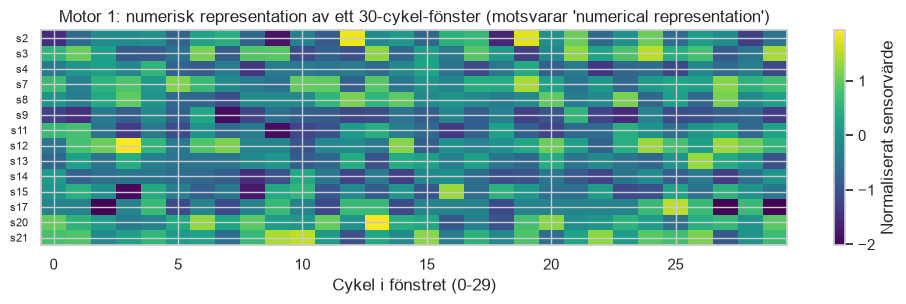

Formen på ett enskilt fönster: (30, 14) (cykler, sensorer)


In [7]:
example_unit = 1
example_window = train_df[train_df["unit"] == example_unit].sort_values("cycle")[SENSOR_COLS].values[:WINDOW]

fig, ax = plt.subplots(figsize=(10, 3.2))
im = ax.imshow(example_window.T, aspect="auto", cmap="viridis")
ax.set_yticks(range(len(SENSOR_COLS)))
ax.set_yticklabels(SENSOR_COLS, fontsize=8)
ax.set_xlabel("Cykel i fönstret (0-29)")
ax.set_title(f"Motor {example_unit}: numerisk representation av ett 30-cykel-fönster (motsvarar 'numerical representation')")
plt.colorbar(im, ax=ax, label="Normaliserat sensorvärde")
plt.tight_layout()
save_fig("tcn_step1_numerical_representation")
plt.show()

print("Formen på ett enskilt fönster:", example_window.shape, "(cykler, sensorer)")

**Vad gör det här blocket?**

Plockar ut ett riktigt fönster (motor 1, de första 30 cyklerna) och visar det som en
heatmap — rader är sensorer, kolumner är cykler, färg är det normaliserade värdet. Precis som
föreläsningens teal-rutor med siffror, fast med 14 sensorer istället för en enda ljudkanal.
Det här är exakt den typen av talmatris som matas in i TCN-modellen.

### 🎓 Steg 2 (föreläsningsbild: "Kernels", dilated convolutions, residual connections)

Här bygger vi själva TCN-arkitekturen: 1D-konvolutionslager med **dilated convolutions**
(filter som hoppar över tidssteg för att se längre bak i tiden) och **residual connections**
(hopplänkar som adderar input till output i varje block) — exakt de två kärnkomponenter
föreläsningen la mest vikt vid.

In [8]:
def build_tcn(window, n_features, dilations=(1, 2, 4, 8), filters=16, kernel_size=3):
    inputs = layers.Input(shape=(window, n_features), name="sensor_window")
    x = inputs
    block_layers = []  # sparar lagren i varje block för att kunna inspektera dem senare
    for i, d in enumerate(dilations):
        conv = layers.Conv1D(
            filters, kernel_size, dilation_rate=d, padding="causal",
            activation="relu", name=f"conv_dilation_{d}",
        )(x)
        # 1x1-konvolution för att göra input-kanalerna kompatibla med residualen
        proj = layers.Conv1D(filters, 1, padding="same", name=f"residual_proj_{i}")(x)
        x = layers.Add(name=f"residual_add_{i}")([conv, proj])
        block_layers.append((conv, proj, x))
    flat = layers.Flatten(name="concatenate_flatten")(x)
    dense = layers.Dense(64, activation="relu", name="dense_hidden")(flat)
    outputs = layers.Dense(n_features, name="prediction")(dense)
    model = models.Model(inputs, outputs, name="tcn_forecaster")
    return model, block_layers

tcn_model, tcn_block_layers = build_tcn(WINDOW, len(SENSOR_COLS))
tcn_model.compile(optimizer="adam", loss="mse")
tcn_model.summary()

Model: "tcn_forecaster"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sensor_window       │ (None, 30, 14)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_dilation_1     │ (None, 30, 16)    │        688 │ sensor_window[0]… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_proj_0     │ (None, 30, 16)    │        240 │ sensor_window[0]… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_add_0      │ (None, 30, 16)    │          0 │ conv_dilation_1[… │
│ (Add)               │                   │            │ residual_proj_0[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_dilation_2     │ (None, 30, 16)    │        784 │ residual_add_0[0… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_proj_1     │ (None, 30, 16)    │        272 │ residual_add_0[0… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_add_1      │ (None, 30, 16)    │          0 │ conv_dilation_2[… │
│ (Add)               │                   │            │ residual_proj_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_dilation_4     │ (None, 30, 16)    │        784 │ residual_add_1[0… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_proj_2     │ (None, 30, 16)    │        272 │ residual_add_1[0… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_add_2      │ (None, 30, 16)    │          0 │ conv_dilation_4[… │
│ (Add)               │                   │            │ residual_proj_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_dilation_8     │ (None, 30, 16)    │        784 │ residual_add_2[0… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_proj_3     │ (None, 30, 16)    │        272 │ residual_add_2[0… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_add_3      │ (None, 30, 16)    │          0 │ conv_dilation_8[… │
│ (Add)               │                   │            │ residual_proj_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_flatten │ (None, 480)       │          0 │ residual_add_3[0… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_hidden        │ (None, 64)        │     30,784 │ concatenate_flat… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ prediction (Dense)  │ (None, 14)        │        910 │ dense_hidden[0][… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 35,790 (139.80 KB)

 Trainable params: 35,790 (139.80 KB)

 Non-trainable params: 0 (0.00 B)

**Vad gör det här blocket?**

Bygger TCN-modellen med samma uppbyggnad som föreläsningen visade:

- **`dilations=(1, 2, 4, 8)`** — fyra block där filtret "hoppar" 1, 2, 4 respektive 8 steg
  mellan de punkter det tittar på. Ju högre dilation, desto längre tillbaka i tiden kan
  modellen "se" utan att behöva fler lager — precis conceptet från föreläsningsbilden.
- **`padding="causal"`** — modellen får bara titta bakåt i tiden, aldrig framåt (rimligt när
  vi ska förutspå nästa steg — den kan ju inte fuska genom att kika på framtiden).
- **Residual connection** i varje block: `conv`-utfallet adderas med en projicerad version av
  blockets input (`proj`). Det säkerställer att ursprunglig information inte går förlorad när
  vi staplar flera block — samma idé som ResNet, som vi redan använde i förra projektet.
- Till sist plattas resultatet ut (`Flatten`) och går genom ett par vanliga `Dense`-lager som
  ger den slutgiltiga förutsägelsen: nästa cykels sensoravläsningar.

In [9]:
EPOCHS_TCN = 25
history_tcn = tcn_model.fit(
    X_tcn_train, y_tcn_train,
    validation_split=0.1, epochs=EPOCHS_TCN, batch_size=64, verbose=1,
)

Epoch 1/25


 1/45 ━━━━━━━━━━━━━━━━━━━━ 1:54 3s/step - loss: 7.7533

12/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.0289 

24/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.0984

38/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.6553

...

 1/45 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.3779

12/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3964 

23/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4073

34/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4076

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4093 - val_loss: 0.5187


**Vad gör det här blocket?**

Tränar TCN-modellen i 25 epoker, bara på de friska fönstren. Modellen lär sig alltså aldrig
hur ett fönster nära ett haveri ser ut — den lär sig bara att förutsäga nästa steg när allt
är normalt.

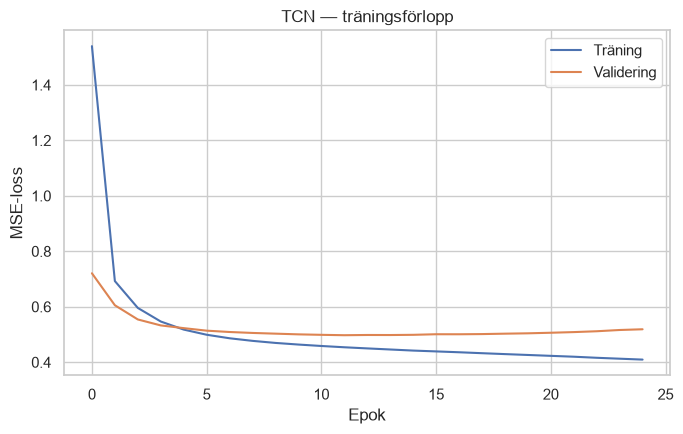

In [10]:
plt.figure(figsize=(7, 4.5))
plt.plot(history_tcn.history["loss"], label="Träning")
plt.plot(history_tcn.history["val_loss"], label="Validering")
plt.title("TCN — träningsförlopp")
plt.xlabel("Epok")
plt.ylabel("MSE-loss")
plt.legend()
plt.tight_layout()
save_fig("tcn_training_curve")
plt.show()

**Vad gör det här blocket?**

Standardkontroll: går tränings- och valideringsförlusten ner tillsammans (bra tecken, modellen
generaliserar) eller börjar de gå isär (tecken på overfitting)?

### 🎓 Steg 3 (föreläsningsbild: "Kernels" — de faktiska filtren)

Nu när modellen är tränad kan vi titta på vad den faktiskt lärde sig. Föreläsningsbilden visar
kernels som små rosa rutor med tre tal (t.ex. `[0.1, 0.9, 0.1]`) — det är precis vad ett
Conv1D-lager med `kernel_size=3` är: en liten vikt-vektor som "glider" längs tidsserien.

Formen på kernel-vikterna: (3, 14, 16) (kernel_size, in_channels, filters)


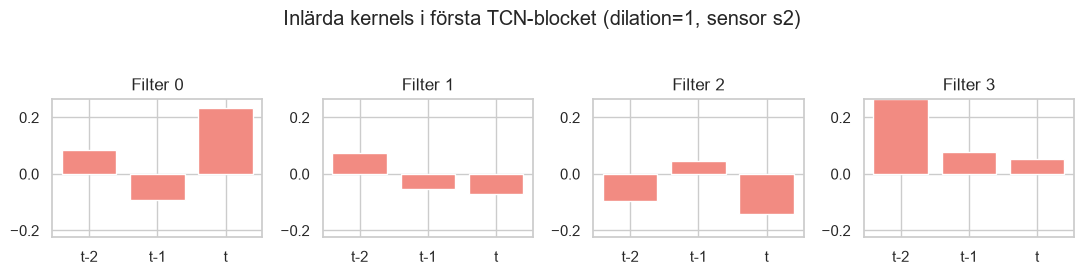

In [11]:
first_conv_layer = tcn_model.get_layer("conv_dilation_1")
kernel_weights, bias = first_conv_layer.get_weights()
print("Formen på kernel-vikterna:", kernel_weights.shape, "(kernel_size, in_channels, filters)")

fig, axes = plt.subplots(1, 4, figsize=(11, 2.6))
for i, ax in enumerate(axes):
    # Visar kernelns tre viktvärden för sensorkanal 0, filter i
    k = kernel_weights[:, 0, i]
    ax.bar(range(3), k, color="#F28B82")
    ax.set_xticks(range(3))
    ax.set_xticklabels(["t-2", "t-1", "t"])
    ax.set_title(f"Filter {i}")
    ax.set_ylim(min(kernel_weights[:, 0, :].min(), -0.1), max(kernel_weights[:, 0, :].max(), 0.1))
plt.suptitle("Inlärda kernels i första TCN-blocket (dilation=1, sensor s2)", y=1.05)
plt.tight_layout()
save_fig("tcn_step3_kernels")
plt.show()

**Vad gör det här blocket?**

Plockar ut de faktiska, inlärda vikterna för det första TCN-blockets filter (dilation=1) och
visar fyra av dem som små stapeldiagram — exakt motsvarigheten till föreläsningens rosa
kernel-rutor, fast med riktiga inlärda tal istället för exempelvärden. Varje filter har lärt
sig sin egen kombination av "hur mycket väger de tre senaste tidsstegen" för att bäst
förutsäga nästa steg.

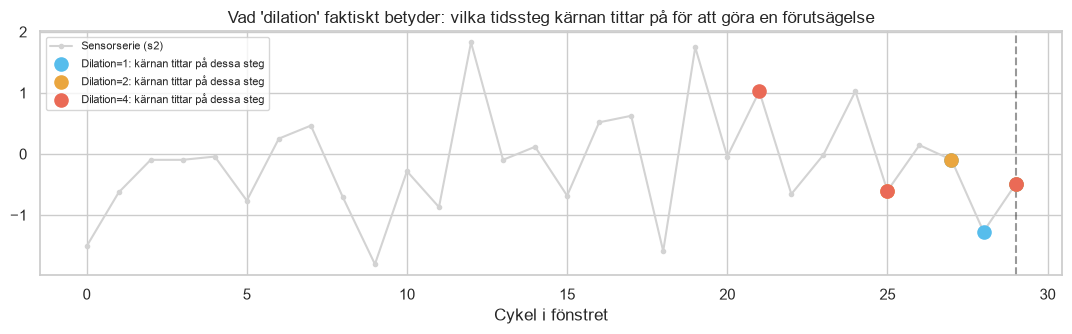

In [12]:
fig, ax = plt.subplots(figsize=(11, 3.5))
cycles = np.arange(WINDOW)
sensor_series = example_window[:, 0]  # sensor s2 för illustrationen
ax.plot(cycles, sensor_series, color="lightgray", marker="o", markersize=3, label="Sensorserie (s2)")

colors = {1: "#57bdec", 2: "#eaa63f", 4: "#ea6a56"}
target_t = WINDOW - 1
for d, c in colors.items():
    touched = [target_t - k * d for k in range(3) if target_t - k * d >= 0]
    ax.scatter(touched, sensor_series[touched], color=c, s=90, zorder=5,
               label=f"Dilation={d}: kärnan tittar på dessa steg")

ax.axvline(target_t, color="black", linestyle="--", alpha=0.4)
ax.set_xlabel("Cykel i fönstret")
ax.set_title("Vad 'dilation' faktiskt betyder: vilka tidssteg kärnan tittar på för att göra en förutsägelse")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
save_fig("tcn_step3_dilation")
plt.show()

**Vad gör det här blocket?**

Det här är kärnan i vad "dilated convolution" betyder, visualiserat på riktig sensordata:
för att göra en förutsägelse vid en given tidpunkt (streckad linje) tittar en kärna med
`dilation=1` bara på de tre senaste stegen i rad. En kärna med `dilation=2` hoppar över
varannat steg och når därmed längre bak i tiden **utan** att behöva fler lager. `dilation=4`
hoppar ännu längre. Det är exakt det här hopp-mönstret föreläsningsbilden visade med
pilarna mellan de teal-rutorna och kernel-rutorna.

### 🎓 Steg 4 (föreläsningsbild: "+ Residual connection")

Föreläsningens diagram visar en orange pil märkt "+ Residual connection" som går runt
`Dot products`/`ReLU`-blocket. Här extraherar vi de faktiska mellanresultaten från vår
tränade modell för att visa exakt vad den adderingen gör.

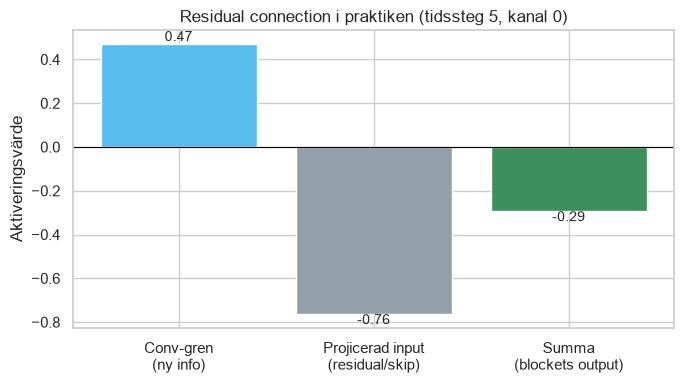

Kontroll: 0.4705 + -0.7634 = -0.2929 (modellens summa: -0.2929)


In [13]:
conv_out_layer, proj_out_layer, add_out_layer = tcn_block_layers[0]
diag_model = models.Model(
    inputs=tcn_model.input,
    outputs=[conv_out_layer, proj_out_layer, add_out_layer],
)
example_batch = X_tcn_train[:1]
conv_out, proj_out, add_out = diag_model.predict(example_batch, verbose=0)

t = 5  # visar kanal 0 vid tidssteg 5 i fönstret, som exempel
fig, ax = plt.subplots(figsize=(7, 4))
labels = ["Conv-gren\n(ny info)", "Projicerad input\n(residual/skip)", "Summa\n(blockets output)"]
values = [conv_out[0, t, 0], proj_out[0, t, 0], add_out[0, t, 0]]
bars = ax.bar(labels, values, color=["#57bdec", "#93a0ab", "#3d8f5b"])
ax.axhline(0, color="black", lw=0.8)
ax.set_title(f"Residual connection i praktiken (tidssteg {t}, kanal 0)")
ax.set_ylabel("Aktiveringsvärde")
for bar, v in zip(bars, values):
    ax.annotate(f"{v:.2f}", (bar.get_x() + bar.get_width()/2, v),
                ha="center", va="bottom" if v >= 0 else "top", fontsize=10)
plt.tight_layout()
save_fig("tcn_step4_residual")
plt.show()

print(f"Kontroll: {conv_out[0,t,0]:.4f} + {proj_out[0,t,0]:.4f} = {conv_out[0,t,0]+proj_out[0,t,0]:.4f} "
      f"(modellens summa: {add_out[0,t,0]:.4f})")

**Vad gör det här blocket?**

Bygger en liten "diagnos-modell" som delar samma vikter som vår riktiga TCN men som lämnar ut
de interna mellanresultaten istället för bara slutgiltiga förutsägelsen. Vi ser konkret att
blockets output verkligen är summan av den nya informationen (`conv`-grenen, det som lärts från
mönstret) och den nästan oförändrade ursprungsinformationen (den projicerade residualen) —
exakt det föreläsningen beskrev: residual connections säkerställer att ursprunglig information
bevaras samtidigt som nätverket lär sig nya, mer komplexa mönster ovanpå den.

### 🎓 Steg 5 (föreläsningsbild: "Concatenate/Flatten" → gula/lila noder → "predictions")

Sista biten av diagrammet: resultatet från alla dilation-block plattas ut och skickas genom
vanliga fullt anslutna lager (de gulgröna/lila cirklarna i bilden) fram till en slutlig
förutsägelse.

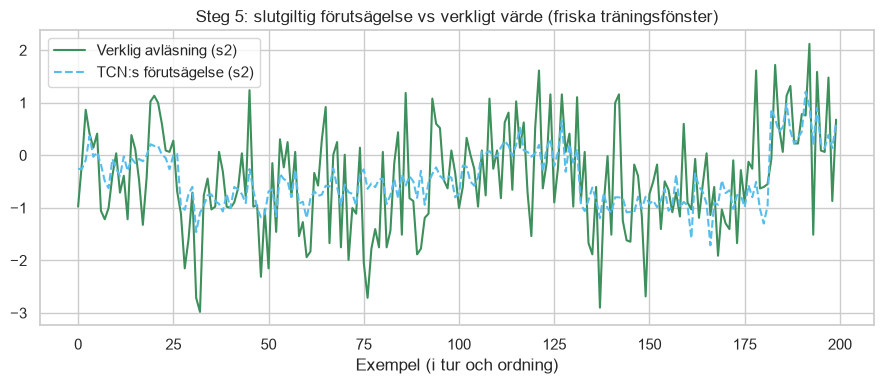

In [14]:
def get_true_and_pred_tcn(model, X, y):
    preds = model.predict(X, verbose=0)
    return y, preds

y_true_sample, y_pred_sample = get_true_and_pred_tcn(tcn_model, X_tcn_train[:200], y_tcn_train[:200])

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(y_true_sample[:, 0], label="Verklig avläsning (s2)", color="#3d8f5b")
ax.plot(y_pred_sample[:, 0], label="TCN:s förutsägelse (s2)", color="#57bdec", linestyle="--")
ax.set_title("Steg 5: slutgiltig förutsägelse vs verkligt värde (friska träningsfönster)")
ax.set_xlabel("Exempel (i tur och ordning)")
ax.legend()
plt.tight_layout()
save_fig("tcn_step5_prediction")
plt.show()

**Vad gör det här blocket?**

Ett sista sanity-check innan vi går vidare till den riktiga utvärderingen: på friska
träningsfönster (som modellen delvis sett liknande exempel av) ska förutsägelsen ligga nära
den verkliga avläsningen. Om de här kurvorna redan hade legat långt ifrån varandra hade något
varit fel i träningen.

### Utvärdering: TCN:s "surprise"-signal över en hel motorlivstid

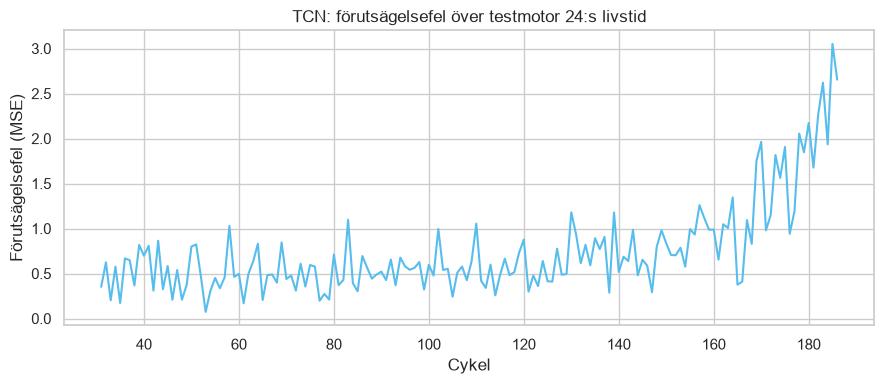

In [15]:
def compute_tcn_forecast_error(model, df, unit_id, sensor_cols, window):
    g = df[df["unit"] == unit_id].sort_values("cycle")
    values = g[sensor_cols].values
    cycles = g["cycle"].values
    X, y, target_cycles = [], [], []
    for i in range(len(g) - window):
        X.append(values[i:i + window])
        y.append(values[i + window])
        target_cycles.append(cycles[i + window])
    X, y = np.array(X), np.array(y)
    preds = model.predict(X, verbose=0)
    error = np.mean((preds - y) ** 2, axis=1)  # MSE över alla sensorer, per cykel
    return np.array(target_cycles), error

EXAMPLE_TEST_UNIT = 24  # en godtycklig testmotor vi återanvänder som exempel genom notebooken

tcn_cycles, tcn_error = compute_tcn_forecast_error(tcn_model, test_df, EXAMPLE_TEST_UNIT, SENSOR_COLS, WINDOW)

plt.figure(figsize=(9, 4))
plt.plot(tcn_cycles, tcn_error, color="#57bdec")
plt.title(f"TCN: förutsägelsefel över testmotor {EXAMPLE_TEST_UNIT}:s livstid")
plt.xlabel("Cykel")
plt.ylabel("Förutsägelsefel (MSE)")
plt.tight_layout()
save_fig("tcn_lifetime_error")
plt.show()

**Vad gör det här blocket?**

Nu kör vi modellen genom **hela** livstiden för en testmotor (som den aldrig sett under
träning), cykel för cykel, och mäter hur fel den blir varje gång. Det här är TCN:s
"surprise"-signal — vår kandidat till larm nummer 1. Håll utkik efter om felet ligger stabilt
lågt i början och sedan **spikar** närmare motorns haveri.

---
## Del 2: Autoencoder — "Känner den igen helheten?"

Samma upplägg som ovan, men nu kopplat till föreläsningens Autoencoder-diagram
(Input → Encoder → Bottleneck/Latent Space → Decoder → Output).

### 🎓 Steg 1 (föreläsningsbild: "Input")

Föreläsningens diagram visar 5 gröna input-noder. Vår input är egentligen ett helt fönster
(30 cykler × 14 sensorer = 420 värden) plattat till en enda lång vektor — samma princip,
bara fler dimensioner än de fem noderna i illustrationen.

Input-dimension till Autoencodern: 30 cykler x 14 sensorer = 420 värden


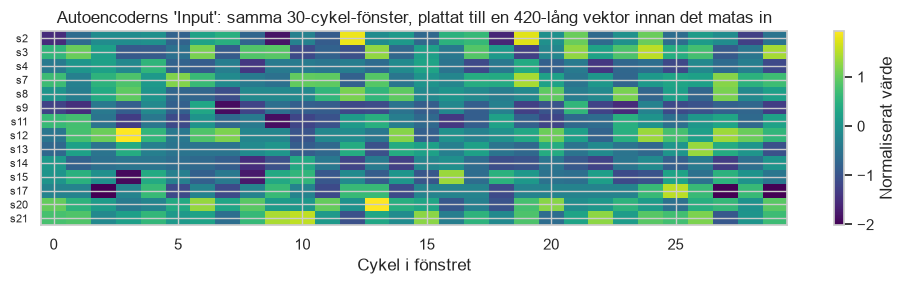

In [16]:
INPUT_DIM = WINDOW * len(SENSOR_COLS)
print(f"Input-dimension till Autoencodern: {WINDOW} cykler x {len(SENSOR_COLS)} sensorer = {INPUT_DIM} värden")

fig, ax = plt.subplots(figsize=(10, 3))
im = ax.imshow(example_window.T, aspect="auto", cmap="viridis")
ax.set_yticks(range(len(SENSOR_COLS)))
ax.set_yticklabels(SENSOR_COLS, fontsize=8)
ax.set_xlabel("Cykel i fönstret")
ax.set_title("Autoencoderns 'Input': samma 30-cykel-fönster, plattat till en 420-lång vektor innan det matas in")
plt.colorbar(im, ax=ax, label="Normaliserat värde")
plt.tight_layout()
save_fig("ae_step1_input")
plt.show()

**Vad gör det här blocket?**

Samma exempel-fönster som i TCN-delen (för att kunna jämföra rakt av), men nu visat som
Autoencoderns "Input" — precis som föreläsningens gröna input-noder, fast med 420 värden
istället för 5.

### 🎓 Steg 2 (föreläsningsbild: "Encoder" och "Decoder")

Bygger encoder-decoder-arkitekturen: lager som gradvis krymper representationen
(Encoder), följt av lager som gradvis bygger upp den igen (Decoder) — de gula respektive
gröna pilarna i föreläsningsdiagrammet.

In [17]:
def build_autoencoder(input_dim, encoding_dims=(128, 32), latent_dim=8):
    inputs = layers.Input(shape=(input_dim,), name="flattened_window")
    x = inputs
    for i, d in enumerate(encoding_dims):
        x = layers.Dense(d, activation="relu", name=f"encoder_{i}")(x)
    latent = layers.Dense(latent_dim, activation="relu", name="latent_space")(x)
    x = latent
    for i, d in enumerate(reversed(encoding_dims)):
        x = layers.Dense(d, activation="relu", name=f"decoder_{i}")(x)
    outputs = layers.Dense(input_dim, activation="linear", name="reconstruction")(x)
    autoencoder = models.Model(inputs, outputs, name="autoencoder")
    encoder = models.Model(inputs, latent, name="encoder_only")
    return autoencoder, encoder

ae_model, encoder_model = build_autoencoder(INPUT_DIM)
ae_model.compile(optimizer="adam", loss="mse")
ae_model.summary()

print("\nDimensioner genom nätverket (motsvarar tratt-formen i föreläsningsbilden):")
for layer in ae_model.layers:
    if hasattr(layer, "units"):
        print(f"  {layer.name:16s} -> {layer.units} noder")

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flattened_window (InputLayer)   │ (None, 420)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_0 (Dense)               │ (None, 128)            │        53,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_1 (Dense)               │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_space (Dense)            │ (None, 8)              │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_0 (Dense)               │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_1 (Dense)               │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruction (Dense)          │ (None, 420)            │        54,180 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 116,972 (456.92 KB)

 Trainable params: 116,972 (456.92 KB)

 Non-trainable params: 0 (0.00 B)


Dimensioner genom nätverket (motsvarar tratt-formen i föreläsningsbilden):
  encoder_0        -> 128 noder
  encoder_1        -> 32 noder
  latent_space     -> 8 noder
  decoder_0        -> 32 noder
  decoder_1        -> 128 noder
  reconstruction   -> 420 noder


**Vad gör det här blocket?**

`encoding_dims=(128, 32)` och `latent_dim=8` betyder: 420 → 128 → 32 → **8** (flaskhalsen) →
32 → 128 → 420. Precis som föreläsningens tratt-diagram: input och output har samma storlek,
och mitten i nätverket är den smalaste punkten — det är där modellen tvingas komprimera all
information till bara det viktigaste.

In [18]:
EPOCHS_AE = 40
history_ae = ae_model.fit(
    X_ae_train, X_ae_train,
    validation_split=0.1, epochs=EPOCHS_AE, batch_size=64, verbose=1,
)

Epoch 1/40


 1/46 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step - loss: 1.0146

26/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8695

46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.8121 - val_loss: 0.6656


Epoch 2/40


...

Epoch 40/40


 1/46 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.4607

21/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4547 

41/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4554

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4553 - val_loss: 0.4587


**Vad gör det här blocket?**

Tränar Autoencodern att återskapa sin egen input (`X_ae_train` som både input och mål), bara
på friska fönster — exakt samma "tränas bara på frisk data"-princip som TCN.

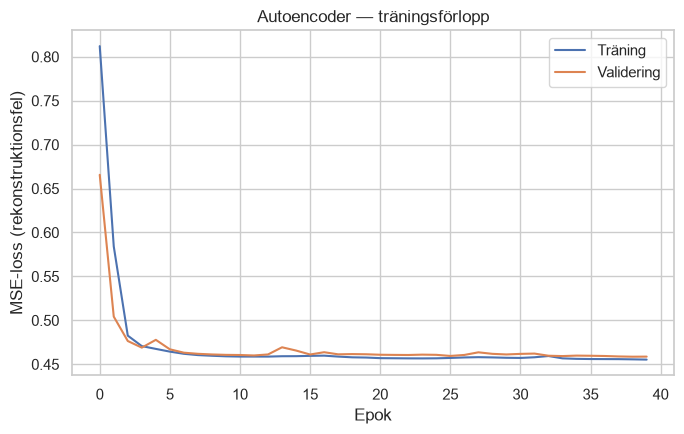

In [19]:
plt.figure(figsize=(7, 4.5))
plt.plot(history_ae.history["loss"], label="Träning")
plt.plot(history_ae.history["val_loss"], label="Validering")
plt.title("Autoencoder — träningsförlopp")
plt.xlabel("Epok")
plt.ylabel("MSE-loss (rekonstruktionsfel)")
plt.legend()
plt.tight_layout()
save_fig("ae_training_curve")
plt.show()

### 🎓 Steg 3 (föreläsningsbild: "Bottleneck" / "Latent Space")

Här extraherar vi den faktiska, komprimerade representationen (de lila noderna i mitten av
föreläsningsdiagrammet) för två olika exempel: ett friskt fönster och ett fönster nära ett
haveri — och jämför.

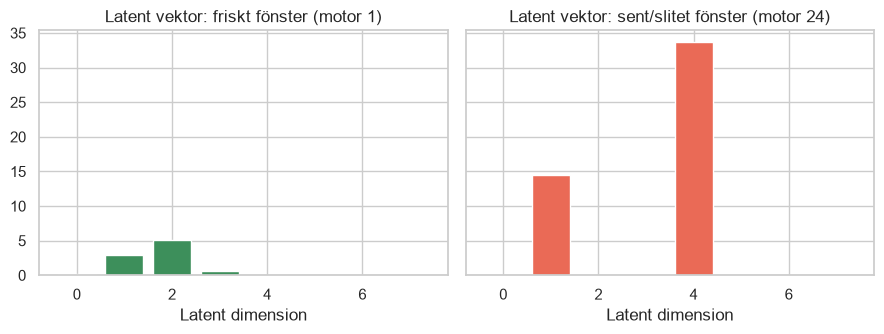

Friskt fönster, latent vektor:   [0.23 2.97 5.15 0.57 0.   0.   0.   0.  ]
Slitet fönster, latent vektor:   [ 0.   14.47  0.    0.   33.68  0.    0.    0.  ]


In [20]:
healthy_example = train_df[(train_df["unit"] == example_unit)].sort_values("cycle")[SENSOR_COLS].values[:WINDOW]
degraded_unit_data = test_df[test_df["unit"] == EXAMPLE_TEST_UNIT].sort_values("cycle")[SENSOR_COLS].values
degraded_example = degraded_unit_data[-WINDOW:]  # de sista (troligen mest slitna) cyklerna

healthy_latent = encoder_model.predict(healthy_example.flatten()[None, :], verbose=0)[0]
degraded_latent = encoder_model.predict(degraded_example.flatten()[None, :], verbose=0)[0]

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5), sharey=True)
axes[0].bar(range(len(healthy_latent)), healthy_latent, color="#3d8f5b")
axes[0].set_title(f"Latent vektor: friskt fönster (motor {example_unit})")
axes[1].bar(range(len(degraded_latent)), degraded_latent, color="#ea6a56")
axes[1].set_title(f"Latent vektor: sent/slitet fönster (motor {EXAMPLE_TEST_UNIT})")
for ax in axes:
    ax.set_xlabel("Latent dimension")
plt.tight_layout()
save_fig("ae_step3_bottleneck")
plt.show()

print("Friskt fönster, latent vektor:  ", np.round(healthy_latent, 2))
print("Slitet fönster, latent vektor:  ", np.round(degraded_latent, 2))

**Vad gör det här blocket?**

Det här är själva flaskhalsen i praktiken: samma modell komprimerar ett friskt respektive ett
slitet fönster till bara 8 tal vardera. Om modellen faktiskt lärt sig något meningsfullt om
"vad som är normalt" ska de här två mönstren se tydligt olika ut — vilket är precis vad vi
förväntar oss se här, eftersom modellen bara någonsin sett friska mönster under träning och
därför inte har någon bra, inlärd komprimering för det slitna fönstret.

### 🎓 Steg 4 (föreläsningsbild: "Decoder" och "Output")

Sista biten: bygger tillbaka en full rekonstruktion från den komprimerade representationen,
och jämför den mot originalet — precis som de gröna output-noderna i föreläsningsdiagrammet.

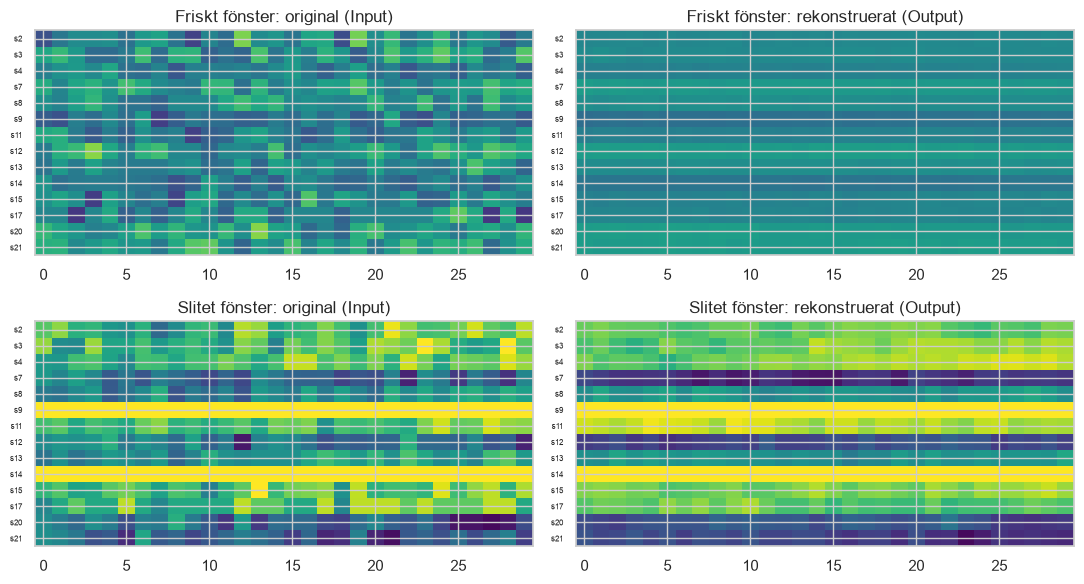

Rekonstruktionsfel (MSE), friskt fönster:  0.457
Rekonstruktionsfel (MSE), slitet fönster:  1.472


In [21]:
healthy_recon = ae_model.predict(healthy_example.flatten()[None, :], verbose=0)[0].reshape(WINDOW, -1)
degraded_recon = ae_model.predict(degraded_example.flatten()[None, :], verbose=0)[0].reshape(WINDOW, -1)

fig, axes = plt.subplots(2, 2, figsize=(11, 6))
vmin, vmax = -3, 3
axes[0, 0].imshow(healthy_example.T, aspect="auto", cmap="viridis", vmin=vmin, vmax=vmax)
axes[0, 0].set_title("Friskt fönster: original (Input)")
axes[0, 1].imshow(healthy_recon.T, aspect="auto", cmap="viridis", vmin=vmin, vmax=vmax)
axes[0, 1].set_title("Friskt fönster: rekonstruerat (Output)")
axes[1, 0].imshow(degraded_example.T, aspect="auto", cmap="viridis", vmin=vmin, vmax=vmax)
axes[1, 0].set_title("Slitet fönster: original (Input)")
axes[1, 1].imshow(degraded_recon.T, aspect="auto", cmap="viridis", vmin=vmin, vmax=vmax)
axes[1, 1].set_title("Slitet fönster: rekonstruerat (Output)")
for ax in axes.flat:
    ax.set_yticks(range(len(SENSOR_COLS)))
    ax.set_yticklabels(SENSOR_COLS, fontsize=6)
plt.tight_layout()
save_fig("ae_step4_decoder_output")
plt.show()

healthy_mse = np.mean((healthy_example - healthy_recon) ** 2)
degraded_mse = np.mean((degraded_example - degraded_recon) ** 2)
print(f"Rekonstruktionsfel (MSE), friskt fönster:  {healthy_mse:.3f}")
print(f"Rekonstruktionsfel (MSE), slitet fönster:  {degraded_mse:.3f}")

**Vad gör det här blocket?**

Fyra heatmaps sida vid sida: originalet och rekonstruktionen för både ett friskt och ett
slitet fönster. **Det här ska vi hålla utkik efter:** det friska fönstrets rekonstruktion
(uppe till höger) ska likna originalet väl — modellen känner igen mönstret. Det slitna
fönstrets rekonstruktion (nere till höger) ska likna originalet **sämre** — modellen har
aldrig sett ett sånt mönster och gissar därför fel. Siffrorna under bilderna bekräftar det
kvantitativt.

### Utvärdering: Autoencoderns "gradvis drift"-signal över en hel motorlivstid

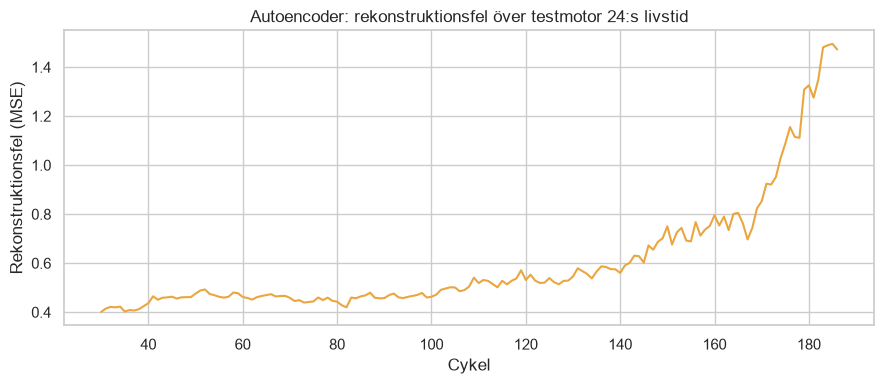

In [22]:
def compute_ae_reconstruction_error(model, df, unit_id, sensor_cols, window):
    g = df[df["unit"] == unit_id].sort_values("cycle")
    values = g[sensor_cols].values
    cycles = g["cycle"].values
    X, target_cycles = [], []
    for i in range(len(g) - window + 1):
        X.append(values[i:i + window].flatten())
        target_cycles.append(cycles[i + window - 1])  # sista cykeln i fönstret
    X = np.array(X)
    recon = model.predict(X, verbose=0)
    error = np.mean((recon - X) ** 2, axis=1)
    return np.array(target_cycles), error

ae_cycles, ae_error = compute_ae_reconstruction_error(ae_model, test_df, EXAMPLE_TEST_UNIT, SENSOR_COLS, WINDOW)

plt.figure(figsize=(9, 4))
plt.plot(ae_cycles, ae_error, color="#eaa63f")
plt.title(f"Autoencoder: rekonstruktionsfel över testmotor {EXAMPLE_TEST_UNIT}:s livstid")
plt.xlabel("Cykel")
plt.ylabel("Rekonstruktionsfel (MSE)")
plt.tight_layout()
save_fig("ae_lifetime_error")
plt.show()

**Vad gör det här blocket?**

Samma typ av "kör genom hela livstiden"-analys som för TCN, fast med rekonstruktionsfel
istället för förutsägelsefel. Håll utkik efter en **mjuk, stigande trend** snarare än en
plötslig spik — det är det mönster teorin förutspådde för den här sortens gradvisa slitage.

---
## Del 3: Rättvis jämförelse mot facit (sann RUL)

TCN:s och Autoencoderns felvärden går inte att jämföra rakt av — olika skala, olika
betydelse. Här utvärderar vi båda på samma sätt mot samma facit.

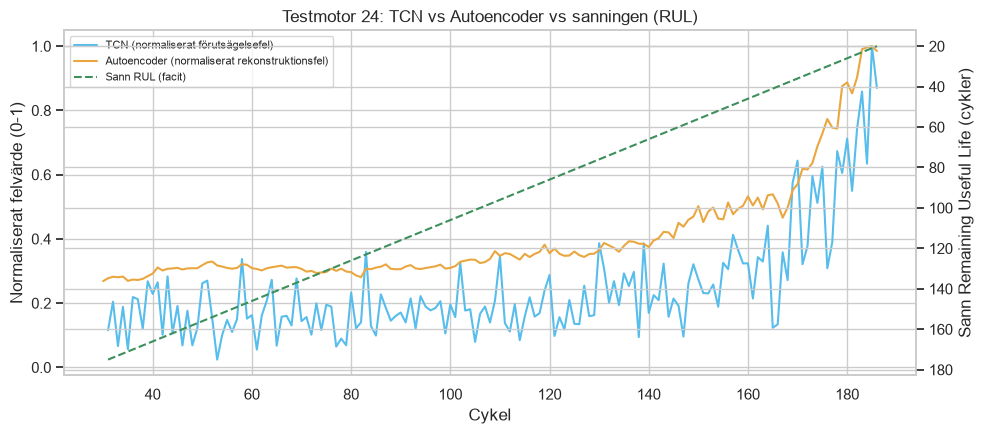

In [23]:
def true_rul_for_cycles(unit_id, cycles, rul_df, df):
    last_cycle = df[df["unit"] == unit_id]["cycle"].max()
    rul_at_cutoff = rul_df.loc[rul_df["unit"] == unit_id, "RUL_at_cutoff"].values[0]
    return rul_at_cutoff + (last_cycle - cycles)

tcn_rul = true_rul_for_cycles(EXAMPLE_TEST_UNIT, tcn_cycles, rul_df, test_df)
ae_rul = true_rul_for_cycles(EXAMPLE_TEST_UNIT, ae_cycles, rul_df, test_df)

fig, ax1 = plt.subplots(figsize=(10, 4.5))
ax1.plot(tcn_cycles, tcn_error / tcn_error.max(), color="#57bdec", label="TCN (normaliserat förutsägelsefel)")
ax1.plot(ae_cycles, ae_error / ae_error.max(), color="#eaa63f", label="Autoencoder (normaliserat rekonstruktionsfel)")
ax1.set_xlabel("Cykel")
ax1.set_ylabel("Normaliserat felvärde (0-1)")

ax2 = ax1.twinx()
ax2.plot(tcn_cycles, tcn_rul, color="#3d8f5b", linestyle="--", label="Sann RUL (facit)")
ax2.set_ylabel("Sann Remaining Useful Life (cykler)")
ax2.invert_yaxis()

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=8)
plt.title(f"Testmotor {EXAMPLE_TEST_UNIT}: TCN vs Autoencoder vs sanningen (RUL)")
plt.tight_layout()
save_fig("comparison_example_engine")
plt.show()

**Vad gör det här blocket?**

Den viktigaste enskilda grafen i hela notebooken: TCN:s felkurva, Autoencoderns felkurva, och
den sanna RUL:en (omvänd axel — sjunker mot slutet) för samma motor, i samma bild. Om
teorin stämmer ska Autoencoderns kurva stiga tidigare/tydligare i takt med att RUL sjunker,
medan TCN:s kurva mest bara spikar precis vid plötsliga avvikelser.

In [24]:
def evaluate_all_test_engines(model_predict_fn, df, rul_df, sensor_cols, window):
    all_cycles, all_errors, all_true_rul, all_units = [], [], [], []
    for unit_id in df["unit"].unique():
        cycles, error = model_predict_fn(df, unit_id, sensor_cols, window)
        rul = true_rul_for_cycles(unit_id, cycles, rul_df, df)
        all_cycles.append(cycles)
        all_errors.append(error)
        all_true_rul.append(rul)
        all_units.append(np.full(len(cycles), unit_id))
    return (np.concatenate(all_units), np.concatenate(all_cycles),
            np.concatenate(all_errors), np.concatenate(all_true_rul))

tcn_units, tcn_all_cycles, tcn_all_error, tcn_all_rul = evaluate_all_test_engines(
    lambda df, u, s, w: compute_tcn_forecast_error(tcn_model, df, u, s, w),
    test_df, rul_df, SENSOR_COLS, WINDOW,
)
ae_units, ae_all_cycles, ae_all_error, ae_all_rul = evaluate_all_test_engines(
    lambda df, u, s, w: compute_ae_reconstruction_error(ae_model, df, u, s, w),
    test_df, rul_df, SENSOR_COLS, WINDOW,
)

tcn_corr = np.corrcoef(tcn_all_error, tcn_all_rul)[0, 1]
ae_corr = np.corrcoef(ae_all_error, ae_all_rul)[0, 1]
print(f"Korrelation (fel vs sjunkande RUL) — TCN:         {tcn_corr:+.3f}")
print(f"Korrelation (fel vs sjunkande RUL) — Autoencoder: {ae_corr:+.3f}")
print("(negativ korrelation = felet stiger när RUL sjunker, vilket är önskat)")

Korrelation (fel vs sjunkande RUL) — TCN:         -0.320
Korrelation (fel vs sjunkande RUL) — Autoencoder: -0.357
(negativ korrelation = felet stiger när RUL sjunker, vilket är önskat)


**Vad gör det här blocket?**

Kör evalueringen på **alla** 100 testmotorer (inte bara vårt exempel), och räknar ut
**korrelationen** mellan varje modells felsignal och den sanna RUL:en, poolat över alla
motorer och cykler. En stark negativ korrelation betyder att felet konsekvent stiger när
motorn närmar sig sitt haveri — precis det vi vill se. Det här är det första av våra två
gemensamt överenskomna, rättvisa jämförelsemått.

In [25]:
def lead_time_analysis(units, cycles, error, true_rul, healthy_threshold):
    lead_times = []
    caught = 0
    for unit_id in np.unique(units):
        mask = units == unit_id
        u_cycles, u_error, u_rul = cycles[mask], error[mask], true_rul[mask]
        order = np.argsort(u_cycles)
        u_error, u_rul = u_error[order], u_rul[order]
        above = np.where(u_error > healthy_threshold)[0]
        if len(above) > 0:
            caught += 1
            lead_times.append(u_rul[above[0]])
    return lead_times, caught, len(np.unique(units))

# Tröskelvärde: 95:e percentilen av felet på FRISK träningsdata (samma logik som föreläsningens bedrägerifall)
tcn_healthy_cycles, tcn_healthy_error = compute_tcn_forecast_error(tcn_model, train_df[train_df["is_healthy"]], example_unit, SENSOR_COLS, WINDOW) \
    if False else (None, None)  # se not nedan

# Vi beräknar tröskeln över alla friska träningsfönster på en gång (snabbare):
tcn_train_preds = tcn_model.predict(X_tcn_train, verbose=0)
tcn_healthy_errors_all = np.mean((tcn_train_preds - y_tcn_train) ** 2, axis=1)
tcn_threshold = np.percentile(tcn_healthy_errors_all, 95)

ae_train_recon = ae_model.predict(X_ae_train, verbose=0)
ae_healthy_errors_all = np.mean((ae_train_recon - X_ae_train) ** 2, axis=1)
ae_threshold = np.percentile(ae_healthy_errors_all, 95)

tcn_leadtimes, tcn_caught, n_engines = lead_time_analysis(tcn_units, tcn_all_cycles, tcn_all_error, tcn_all_rul, tcn_threshold)
ae_leadtimes, ae_caught, _ = lead_time_analysis(ae_units, ae_all_cycles, ae_all_error, ae_all_rul, ae_threshold)

print(f"TCN:         larmade för {tcn_caught}/{n_engines} motorer, medel-förvarningstid = {np.mean(tcn_leadtimes):.1f} cykler")
print(f"Autoencoder: larmade för {ae_caught}/{n_engines} motorer, medel-förvarningstid = {np.mean(ae_leadtimes):.1f} cykler")

TCN:         larmade för 98/100 motorer, medel-förvarningstid = 170.1 cykler
Autoencoder: larmade för 76/100 motorer, medel-förvarningstid = 151.7 cykler


**Vad gör det här blocket?**

Vårt andra gemensamt överenskomna mått: **förvarningstid**. Vi sätter ett tröskelvärde för
"onormalt" baserat på den 95:e percentilen av felet på frisk träningsdata (samma tröskel-logik
som föreläsningens bedrägeriexempel). Sedan mäter vi, för varje testmotor, hur många cykler
innan haveriet som felet först passerade tröskeln — det är den faktiska förvarningstiden en
odlare (eller här: ett underhållsteam) hade fått i praktiken.

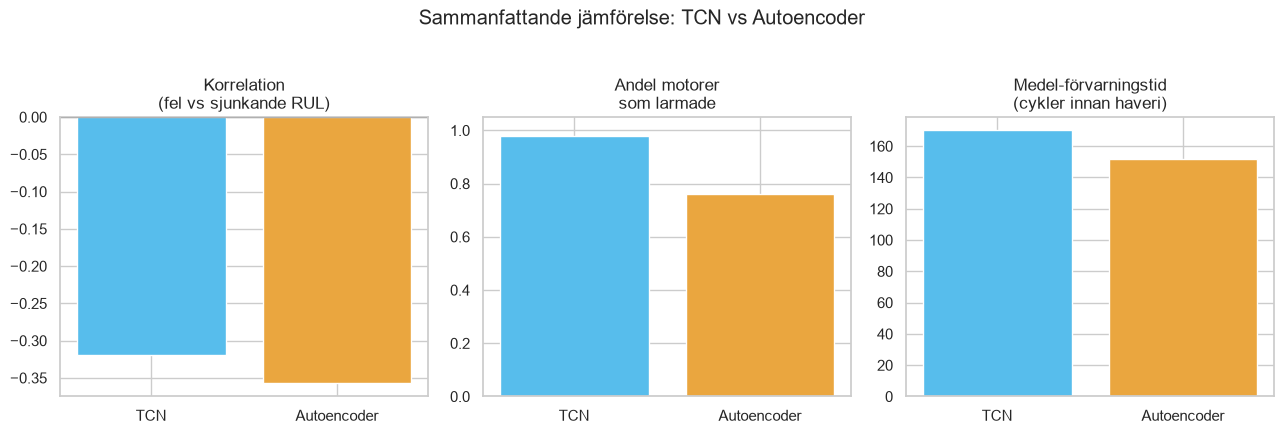

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))

axes[0].bar(["TCN", "Autoencoder"], [tcn_corr, ae_corr], color=["#57bdec", "#eaa63f"])
axes[0].axhline(0, color="black", lw=0.8)
axes[0].set_title("Korrelation\n(fel vs sjunkande RUL)")

axes[1].bar(["TCN", "Autoencoder"], [tcn_caught / n_engines, ae_caught / n_engines], color=["#57bdec", "#eaa63f"])
axes[1].set_title("Andel motorer\nsom larmade")
axes[1].set_ylim(0, 1.05)

axes[2].bar(["TCN", "Autoencoder"], [np.mean(tcn_leadtimes), np.mean(ae_leadtimes)], color=["#57bdec", "#eaa63f"])
axes[2].set_title("Medel-förvarningstid\n(cykler innan haveri)")

plt.suptitle("Sammanfattande jämförelse: TCN vs Autoencoder", y=1.03)
plt.tight_layout()
save_fig("final_comparison")
plt.show()

**Vad gör det här blocket?**

Sammanfattar alla tre jämförelsemåtten i en enda bild — den här är kandidaten till
huvudbilden för min presentationsdel (slide 11-15). Det är här svaret på gruppens
grundfråga ("vilken fråga ger tydligast varning för just den här sortens slitage?") blir
konkret och mätbart.

---
## Affärsvärde och slutsats

**Vad har vi visat?** Att två helt olika sätt att fråga "är den här motorn på väg att gå
sönder?" — en som frågar "blev jag förvånad just nu?" (TCN) och en som frågar "känner jag
igen hela mönstret?" (Autoencoder) — båda går att bygga från grunden, tränas bara på frisk
data, och validera mot ett verkligt facit (sann Remaining Useful Life).

**Kopplingen till föreläsningen:** Båda modellerna bygger på samma byggstenar som visades i
föreläsningen — TCN:s dilated convolutions och residual connections, Autoencoderns
encoder/bottleneck/decoder-struktur — men här kopplade till en konkret, verklig
tillämpning (jetmotorer) istället för de abstrakta exemplen i slides.

**Varför är det här värdefullt för ett flygbolag/underhållsteam?**
- **Tidigare upptäckt** av potentiella motorproblem, innan de blir kritiska.
- **Planerat istället för akut underhåll** — lägre kostnad, mindre driftstopp.
- **Två kompletterande perspektiv** — plötsliga avvikelser (TCN) och smygande slitage
  (Autoencoder) täcks båda, istället för att bara förlita sig på en enda detektionsmetod.

**Begränsningar:** C-MAPSS är simulerad data (inte riktiga flygningar), begränsad till ett
driftsförhållande och en feltyp (FD001). Verkliga sensordata i drift skulle sannolikt vara
brusigare och mer varierad. Det här är ett proof-of-concept, inte ett produktionsklart system.